In [ ]:
import pandas as pd
import os 
import numpy as np
import struct
from datetime import datetime, date, timedelta 
import tqdm as tqdm
import pickle

import matplotlib.pyplot as plt
import scipy as sp


In [ ]:
RECL = 8510

In [ ]:
def getdata(input_file):
    Lt = []
    Al = []
    Lat = []
    Long = []
    dfArray0 = []
    dfArray1 = []
    timel =[]
    RECL = 8510
    with open(input_file, 'rb') as f:
        piece = f.read(RECL)
    
        counter = 0  # count of the number of occurrences of RELC
        while piece:
            counter += 1
            datcds = [int.from_bytes(piece[:4], byteorder='big'), int.from_bytes(piece[4:8], byteorder='big')]
            day=np.mod(datcds[0],16777216)
            msec=datcds[1]
            record_date = date(1950, 1, 1) + timedelta(days=int(day))
            i = 8; delta = 2 * 7
            time = struct.unpack('>'+'h'*7, piece[i:i+delta])
            i = i + delta; delta = 2 * 2

            orb, sorb = struct.unpack('>hh', piece[i:i + delta])
            print(orb,sorb)

            i = i + delta; delta = 8

            tms = "".join([s.decode() for s in struct.unpack('>' +'s'*8, piece[i:i+delta])])

            i = i + delta; delta = 4
            soft_cal = struct.unpack('>bbbb', piece[i:i + delta])

            i = i + delta; delta = 4*4
            orbp = struct.unpack('>ffff', piece[i:i+delta])
            Geocentric_lat = f"{orbp[0]:.4f}"
            Geocentric_long = f"{orbp[1]:.4f}"
            local_time = f"{orbp[3]:.4f}"
            Altitude = f"{orbp[2]:.3f}"
            i += delta; delta = 4*15
            geop = struct.unpack('>'+'f'*15, piece[i:i+delta])


            i += delta; delta = 4*3
            solp = struct.unpack('>'+'f'*3, piece[i:i+delta])

            i = i + delta; delta = 2
            vers = struct.unpack('>bb', piece[i:i + delta])

            i += delta; delta = 4*18
            attp = struct.unpack('>'+'f'*18, piece[i:i+delta])

            i = i + delta; delta = 2
            qi = struct.unpack('>h', piece[i:i + delta])[0]

            i = i + delta; delta = 2
            vers = struct.unpack('>bb', piece[i:i + delta])

            i = i + delta; delta = 21
            type = "".join([s.decode() for s in struct.unpack('>' +'s'*21, piece[i:i+delta])])

            i = i + delta; delta = 32
            hk = struct.unpack('>'+'c'*32, piece[i:i + delta])
            HKs = "".join([el.hex() for el in hk])

            i = i + delta; delta = 9
            coord = "".join([s.decode() for s in struct.unpack('>' +'s'*9, piece[i:i+delta])])

            i = i + delta; delta = 3
            name = "".join([s.decode() for s in struct.unpack('>' +'s'*3, piece[i:i+delta])])

            i = i + delta; delta = 16
            unit = "".join([s.decode('latin-1') for s in struct.unpack('>' +'s'*16, piece[i:i+delta])])

            i = i + delta; delta = 1
            nbsp = struct.unpack('>'+'b'*1, piece[i:i + delta])[0]
            #print(f"Number of consecutice spectra = {nbsp}")
            i = i + delta; delta = 2
            nbf = struct.unpack('>h', piece[i:i + delta])[0]
            #print(f"Number of spectrum frequencies  = {nbf}")
            i += delta; delta = 4
            dt = struct.unpack('>f', piece[i:i+delta])[0]
            
            #print(f"Time duration of one data array = {dt:.4f}")
            i += delta; delta = 4
            freq = struct.unpack('>f', piece[i:i+delta])[0]
            Frequency_resolution = f"{freq:.4f}"
            #print(f"Frequency resolution = {freq:.4f}")
            i += delta; delta = 4*2
            frange = struct.unpack('>ff', piece[i:i+delta])[0]
            #print(f"Frequency range = {frange:.4f}")
            i += delta; delta = 2 * 7
            idatsp = struct.unpack('>'+'h'*7, piece[i:i+delta])
            #print(f"time = {idatsp}")
            i += delta
            sp = struct.unpack('>2048f', piece[i:])
            sp_0 = sp[:1024]
            sp_1 = sp[1024:]
            dfArray0.append(np.array(sp_0)) 
            dfArray1.append(np.array(sp_1)) 
            dt = datetime(year=int(time[0]), month=int(time[1]), day=int(time[2]), hour=int(time[3]),minute=int(time[4]), second=int(time[5]),microsecond=int(time[6])*1000)
            date_time = dt.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]
            timel.append(date_time)
            Lt.append(local_time)
            Al.append(Altitude)
            Lat.append(Geocentric_lat)
            Long.append(Geocentric_long)
            #frq.append(Frequency_resolution)
           
            piece = f.read(RECL)
            OP = pd.DataFrame({'time':timel, 'Geocentric_lat':Lat, 'Geocentric_long':Long, 'Altitude': Al,"Local_time":Lt, 'spectrum0':dfArray0,'spectrum1':dfArray1}) 
            df = pd.concat([OP])
            df.columns=['datetime', 'geo_lat', 'geo_long', 'altitude', 'localtime', 'spectrum0','spectrum1']

    return df

                        

In [ ]:

input_file ="D:\GIT\Demeter-Anomaly-Detection-Framework\Data\DMT_N1_1132_032320_20050209_162037_20050209_165454.DAT"


input_file ="G:\ICE-DAT\ICE-2008\DMT_N1_1132_187000_20080101_131637_20080101_135154.DAT"
data = getdata(input_file)

18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0
18700 0


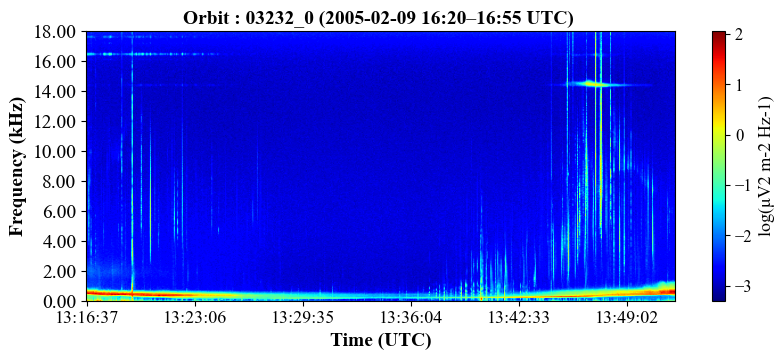

(518, 1024)

In [ ]:

import numpy as  np
import pandas as pd
import os
import matplotlib.pyplot as plt
import scipy as sp
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Set Cambria as default font
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

rcParams['font.size'] = 12     # if you want all text size 12 by default

# data1 = pd.read_pickle('F:\\ASCII_1132\\28-02-2010.pkl')
sp_01 =data['spectrum1'].values
sp_01 = np.array([np.array(x) for x in sp_01])
sp_01 = sp_01.astype(float)
sp_0 =data['spectrum0'].values
sp_0 = np.array([np.array(x) for x in sp_0])
sp_0 = sp_0.astype(float)



# min_freq = 19.035
# max_freq = 18000
#freq_list = np.logspace(np.log10(min_freq), np.log10(max_freq),sp_0.shape[0])
min_freq = 0
max_freq = 18
# Generate a list of frequencies using numpy
freq_list = np.linspace(min_freq, max_freq,10)
freq_list = ["%.2f" % z for z in freq_list]

fig, ax = plt.subplots(figsize=(13,4))
im = ax.imshow(sp_01.T, origin='lower', aspect='auto', cmap='jet')
im = ax.imshow(sp_0.T, origin='lower', aspect='auto', cmap='jet')
ax.set_yticks(np.linspace(0, 1024, 10),freq_list, fontsize =14)

# datetime1 = data['datetime']
# xticks1 = list(range(0, 513, 95))
# ax.set_xticks(xticks1, datetime1[xticks1],fontsize =12)
# Ensure it's a datetime series
datetime1 = pd.to_datetime(data['datetime'])

# Choose tick positions (same as you had)
xticks1 = list(range(0, len(datetime1), 95))

# Set ticks and use only HH:MM as labels
ax.set_xticks(xticks1)
ax.set_xticklabels(datetime1.dt.strftime('%H:%M:%S').iloc[xticks1], fontsize=13, rotation=0)

# ax.set_xlabel('Time (hh:mm)', fontsize=13)

# ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
# Add colorbar
cbar = fig.colorbar(im)
cbar.set_label('log(μV2 m-2 Hz-1)', fontsize =13)
# plt.gca().yaxis.set_major_locator(plt.MaxNLocator(3))
#ax.set_yticks(range(1024), )
# Set the axis labels
plt.title(f'Orbit : 03232_0 (2005-02-09 16:20–16:55 UTC) ', weight='bold',fontsize =14)
ax.set_xlabel('Time (UTC)', weight='bold',fontsize =14)
ax.set_ylabel('Frequency (kHz)',weight='bold', fontsize =14)
# fig.savefig(
#     r"C:\PROJECT-DEMETER\Paper1\plots\fig_2a.png",
#     dpi=600,
#     bbox_inches='tight',   # remove surrounding white margins
#     pad_inches=0           # (optional) no extra padding at all
# )
fig.set_size_inches(9.5, 3.5)  # width, height in inches

# fig.savefig(
#     r"C:\PROJECT-DEMETER\Paper1\plots\fig_2a.eps",
#     dpi=600,
#     bbox_inches="tight"
# )

#print(sp_0,freq_index)
# Show the plot
plt.show()




sp_01.shape

ASCII File Reading


In [ ]:
def getdata1(input_file):
    Lt = []
    Al = []
    Lat = []
    Long = []
    dfArray0 = []
    dfArray1 = []
    timel =[]
    # frq =[]
    with open(input_file, 'rb') as f:
        piece = f.read(RECL)
    
        counter = 0  # count of the number of occurrences of RELC
        while piece:
            counter += 1
            datcds = [int.from_bytes(piece[:4], byteorder='big'), int.from_bytes(piece[4:8], byteorder='big')]
            day=np.mod(datcds[0],16777216)
            msec=datcds[1]
            record_date = date(1950, 1, 1) + timedelta(days=int(day))
            i = 8; delta = 2 * 7
            time = struct.unpack('>'+'h'*7, piece[i:i+delta])
            i = i + delta; delta = 2 * 2

            orb, sorb = struct.unpack('>hh', piece[i:i + delta])

            i = i + delta; delta = 8

            tms = "".join([s.decode() for s in struct.unpack('>' +'s'*8, piece[i:i+delta])])

            i = i + delta; delta = 4
            soft_cal = struct.unpack('>bbbb', piece[i:i + delta])

            i = i + delta; delta = 4*4
            orbp = struct.unpack('>ffff', piece[i:i+delta])
            Geocentric_lat = f"{orbp[0]:.4f}"
            Geocentric_long = f"{orbp[1]:.4f}"
            local_time = f"{orbp[3]:.4f}"
            Altitude = f"{orbp[2]:.3f}"
            i += delta; delta = 4*15
            geop = struct.unpack('>'+'f'*15, piece[i:i+delta])


            i += delta; delta = 4*3
            solp = struct.unpack('>'+'f'*3, piece[i:i+delta])

            i = i + delta; delta = 2
            vers = struct.unpack('>bb', piece[i:i + delta])

            i += delta; delta = 4*18
            attp = struct.unpack('>'+'f'*18, piece[i:i+delta])

            i = i + delta; delta = 2
            qi = struct.unpack('>h', piece[i:i + delta])[0]

            i = i + delta; delta = 2
            vers = struct.unpack('>bb', piece[i:i + delta])

            i = i + delta; delta = 21
            type = "".join([s.decode() for s in struct.unpack('>' +'s'*21, piece[i:i+delta])])

            i = i + delta; delta = 32
            hk = struct.unpack('>'+'c'*32, piece[i:i + delta])
            HKs = "".join([el.hex() for el in hk])

            i = i + delta; delta = 9
            coord = "".join([s.decode() for s in struct.unpack('>' +'s'*9, piece[i:i+delta])])

            i = i + delta; delta = 3
            name = "".join([s.decode() for s in struct.unpack('>' +'s'*3, piece[i:i+delta])])

            i = i + delta; delta = 16
            unit = "".join([s.decode('latin-1') for s in struct.unpack('>' +'s'*16, piece[i:i+delta])])

            i = i + delta; delta = 1
            nbsp = struct.unpack('>'+'b'*1, piece[i:i + delta])[0]
            #print(f"Number of consecutice spectra = {nbsp}")
            i = i + delta; delta = 2
            nbf = struct.unpack('>h', piece[i:i + delta])[0]
            #print(f"Number of spectrum frequencies  = {nbf}")
            i += delta; delta = 4
            dt = struct.unpack('>f', piece[i:i+delta])[0]
            
            #print(f"Time duration of one data array = {dt:.4f}")
            i += delta; delta = 4
            freq = struct.unpack('>f', piece[i:i+delta])[0]
            Frequency_resolution = f"{freq:.4f}"
            #print(f"Frequency resolution = {freq:.4f}")
            i += delta; delta = 4*2
            frange = struct.unpack('>ff', piece[i:i+delta])[0]
            #print(f"Frequency range = {frange:.4f}")
            i += delta; delta = 2 * 7
            idatsp = struct.unpack('>'+'h'*7, piece[i:i+delta])
            # print(f"time = {idatsp}")
            i += delta
            sp = struct.unpack('>2048f', piece[i:])
            sp_0 = sp[:1024]
            sp_1 = sp[1024:]
            dfArray0.append(np.array(sp_0)) 
            dfArray1.append(np.array(sp_1)) 
            dt = datetime(year=int(time[0]), month=int(time[1]), day=int(time[2]), hour=int(time[3]),minute=int(time[4]), second=int(time[5]),microsecond=int(time[6])*1000)
            date_time = dt.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]
            timel.append(date_time)
            Lt.append(local_time)
            Al.append(Altitude)
            Lat.append(Geocentric_lat)
            Long.append(Geocentric_long)
            #frq.append(Frequency_resolution)
           
            piece = f.read(RECL)
            # print(dfArray0)
    return  timel, Lat, Long,Lt, Al, dfArray0, dfArray1,counter
                        

In [ ]:
def consolidateDataframes(timel , Lat , Long, Lt, Al, sp0, sp1 ):
    OP = pd.DataFrame({'time':timel,'Geoc_lat':Lat,'Geoc_long':Long,'Local_time': Lt, 'Altitude':Al, 'spectrum0': sp0,'spectrum1': sp1}) 
    df2 = pd.concat([OP])
    
    df2.columns=['datetime', 'geoc_lat', 'geoc_long','local_time', 'altitude','spectrum0','spectrum1' ]
    #fre = df2.Frequency_Resolution.values
    return df2


In [ ]:
DFlist =[]
count = []
# loop through all files in the folder
folder_path ="D:\GIT\Demeter-Anomaly-Detection-Framework\Data\dat"
# folder_path = "E:\ICE-DAT\\ICE-2005"
RECL = 8510
# loop through all files in the folder
for filename in os.listdir(folder_path):
    Data =list(getdata1(os.path.join(folder_path,filename)))
    P = consolidateDataframes(Data[0],Data[1],Data[2],Data[3],Data[4],Data[5],Data[6])
    output_filename = os.path.splitext(filename[7:])[0] + "_full"+".pkl"
    with open(os.path.join( "D:\GIT\Demeter-Anomaly-Detection-Framework\Data",output_filename), "wb") as k:
        pickle.dump(P, k) #each files will be saved in its corresponding name
    DFlist.append(P) # to save all file in to single file( for example in case of a spectrum of a day (16 orbits a day-concat them together))
    count.append(Data[7])
    #print(f'the count of repeatation of relc : {Data[7]}')
print(sum(count))
result_df = pd.concat(DFlist, axis=0, ignore_index=True)
# result_df.to_pickle('D:\PhD-FBK\ASCII\Orits-together.pkl')

569


In [ ]:
df = pd.read_pickle("D:\GIT\Demeter-Anomaly-Detection-Framework\Data\\1132_032320_20050209_162037_20050209_165454_full.pkl")

In [ ]:
df

,datetime,geoc_lat,geoc_long,local_time,altitude,spectrum0,spectrum1
0,2005-02-09 16:20:36.216,51.3989,278.9475,10.9399,729.287,"[0.6619781851768494, 0.07132355868816376, 0.05...","[0.4658997356891632, 0.1889706254005432, -0.02..."
1,2005-02-09 16:20:40.312,51.1577,278.8412,10.9339,729.220,"[0.42668405175209045, 0.1889706254005432, 0.05...","[0.5443311333656311, 0.22818630933761597, 0.01..."
2,2005-02-09 16:20:44.408,50.9164,278.7349,10.9280,729.154,"[0.5835468173027039, -0.43848034739494324, -0....","[0.7404095530509949, -0.24240192770957947, -0...."
3,2005-02-09 16:20:48.504,50.6751,278.6286,10.9220,729.088,"[0.5443311333656311, -0.24240192770957947, -0....","[0.4658997356891632, -0.3992646634578705, -0.4..."
4,2005-02-09 16:20:52.600,50.4339,278.5223,10.9161,729.021,"[0.5051153898239136, -0.2816176116466522, -0.5...","[0.7404095530509949, -0.2816176116466522, -0.3..."
...,...,...,...,...,...,...,...
496,2005-02-09 16:54:36.772,-69.6844,236.9259,8.7053,725.894,"[1.6031546592712402, 1.3654412031173706, 1.077...","[1.17178213596344, 0.6203431487083435, 0.64632..."
497,2005-02-09 16:54:40.868,-69.9095,236.6000,8.6847,725.911,"[0.9757036566734314, 0.11053924262523651, 0.01...","[0.8972722887992859, -0.08553918451070786, -0...."
498,2005-02-09 16:54:44.964,-70.1345,236.2741,8.6641,725.928,"[1.17178213596344, 0.42426472902297974, 0.0973...","[1.6815860271453857, 1.3262255191802979, 1.234..."
499,2005-02-09 16:54:49.060,-70.3596,235.9482,8.6435,725.946,"[1.0933507680892944, 0.14975492656230927, -0.2...","[1.485507607460022, 1.4830882549285889, 1.7835..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    501 non-null    object
 1   geoc_lat    501 non-null    object
 2   geoc_long   501 non-null    object
 3   local_time  501 non-null    object
 4   altitude    501 non-null    object
 5   spectrum0   501 non-null    object
 6   spectrum1   501 non-null    object
dtypes: object(7)
memory usage: 27.5+ KB


In [ ]:
df['spectrum0'].dtype

dtype('O')

In [ ]:
x = df['spectrum0'].iloc[0]

print("Type:", type(x))
print("Shape:", getattr(x, 'shape', 'No shape attribute'))
print("Length:", len(x))
print("First 10 values:", x[:10])
print("Min:", x.min())
print("Max:", x.max())

Type: <class 'numpy.ndarray'>
Shape: (1024,)
Length: 1024
First 10 values: [ 0.66197819  0.07132356  0.05809401 -0.16592193 -0.38270819 -0.41933578
 -0.56089079 -0.53824043 -0.35412729 -0.16709095]
Min: -2.8710882663726807
Max: 3.959927558898926


GRID DATA

In [ ]:
Grid_df = pd.read_pickle("G:\GRID\Down_Orbits-max-val-location.pkl")

In [ ]:
print("Type:", type(Grid_df))
print("Number of items:", len(Grid_df))
print("\nKeys:")
print(Grid_df.keys())

Type: <class 'dict'>
Number of items: 147

Keys:
dict_keys(['G144', 'G125', 'G107', 'G89', 'G71', 'G52', 'G161', 'G143', 'G142', 'G124', 'G106', 'G88', 'G69', 'G51', 'G160', 'G141', 'G123', 'G105', 'G86', 'G68', 'G50', 'G32', 'G159', 'G140', 'G122', 'G103', 'G85', 'G67', 'G49', 'G30', 'G158', 'G139', 'G120', 'G102', 'G84', 'G66', 'G47', 'G29', 'G138', 'G137', 'G119', 'G101', 'G83', 'G65', 'G64', 'G46', 'G28', 'G135', 'G117', 'G98', 'G80', 'G62', 'G44', 'G26', 'G25', 'G7', 'G134', 'G116', 'G115', 'G97', 'G79', 'G61', 'G43', 'G42', 'G24', 'G132', 'G114', 'G96', 'G78', 'G60', 'G59', 'G41', 'G23', 'G4', 'G131', 'G113', 'G95', 'G77', 'G76', 'G58', 'G40', 'G22', 'G21', 'G130', 'G112', 'G94', 'G93', 'G75', 'G57', 'G39', 'G20', 'G129', 'G111', 'G110', 'G92', 'G74', 'G56', 'G38', 'G37', 'G19', 'G128', 'G109', 'G91', 'G73', 'G55', 'G72', 'G54', 'G36', 'G127', 'G126', 'G108', 'G90', 'G53', 'G35', 'G70', 'G87', 'G104', 'G31', 'G100', 'G82', 'G27', 'G136', 'G118', 'G99', 'G81', 'G63', 'G45', 'G133'

In [ ]:
for key, value in Grid_df.items():
    print(
        f"{key:10} | "
        f"type={type(value).__name__:15} | "
        f"shape={getattr(value, 'shape', 'N/A')} | "
        f"length={len(value) if hasattr(value, '__len__') else 'N/A'}"
    )

G144       | type=list            | shape=N/A | length=54637
G125       | type=list            | shape=N/A | length=50435
G107       | type=list            | shape=N/A | length=37818
G89        | type=list            | shape=N/A | length=49225
G71        | type=list            | shape=N/A | length=44737
G52        | type=list            | shape=N/A | length=44198
G161       | type=list            | shape=N/A | length=11869
G143       | type=list            | shape=N/A | length=41987
G142       | type=list            | shape=N/A | length=35816
G124       | type=list            | shape=N/A | length=49687
G106       | type=list            | shape=N/A | length=49093
G88        | type=list            | shape=N/A | length=35321
G69        | type=list            | shape=N/A | length=40612
G51        | type=list            | shape=N/A | length=50941
G160       | type=list            | shape=N/A | length=18150
G141       | type=list            | shape=N/A | length=47080
G123       | type=list  

In [ ]:
Grid_df['G23'][0:15]

[{'fb_1': {'datetime': Timestamp('2005-01-01 15:29:46.228000'),
   'max': -0.2007669359445572,
   'Q3': -1.3478257954120636,
   'lat': -50.2431,
   'lon': -88.87119999999999}},
 {'fb_2': {'datetime': Timestamp('2005-01-01 15:29:46.228000'),
   'max': -0.3195798397064209,
   'Q3': -1.5323859453201294,
   'lat': -50.2431,
   'lon': -88.87119999999999}},
 {'fb_3': {'datetime': Timestamp('2005-01-01 15:29:46.228000'),
   'max': 1.0428268909454346,
   'Q3': 0.60041543841362,
   'lat': -50.2431,
   'lon': -88.87119999999999}},
 {'fb_4': {'datetime': Timestamp('2005-01-01 15:29:46.228000'),
   'max': 0.8419267535209656,
   'Q3': 0.40038981288671494,
   'lat': -50.2431,
   'lon': -88.87119999999999}},
 {'fb_5': {'datetime': Timestamp('2005-01-01 15:29:46.228000'),
   'max': 0.9645294547080994,
   'Q3': 0.4703562930226326,
   'lat': -50.2431,
   'lon': -88.87119999999999}},
 {'fb_6': {'datetime': Timestamp('2005-01-01 15:29:46.228000'),
   'max': 0.9227157831192017,
   'Q3': 0.4373523071408272,

In [ ]:
records = Grid_df['G29']

rows = []

for record in records:
    fb = list(record.keys())[0]
    data = record[fb]

    rows.append({
        'datetime': data['datetime'],
        'lat': data['lat'],
        'lon': data['lon'],
        'fb': fb,
        'Q3': data['Q3']
    })

temp_df = pd.DataFrame(rows)

ts = temp_df.pivot(
    index=['datetime', 'lat', 'lon'],
    columns='fb',
    values='Q3'
).reset_index()


ts.columns.name = None

ts = ts.rename(columns={
    f'fb_{i}': f'Q3_fb_{i}' for i in range(1, 12)
})

ts = ts[['datetime', 'lat', 'lon'] + [f'Q3_fb_{i}' for i in range(1, 12)]]
ts

,datetime,lat,lon,Q3_fb_1,Q3_fb_2,Q3_fb_3,Q3_fb_4,Q3_fb_5,Q3_fb_6,Q3_fb_7,Q3_fb_8,Q3_fb_9,Q3_fb_10,Q3_fb_11
0,2005-01-01 07:14:56.282,-51.0621,34.5389,-0.122336,-0.983366,0.851671,1.418194,1.842281,2.059971,2.107233,1.964151,1.520741,1.144877,0.911945
1,2005-01-01 07:16:59.162,-58.2320,30.8253,0.230606,-1.140229,0.530568,1.339763,1.829823,2.013743,2.011537,1.753584,1.518908,1.160467,1.023045
2,2005-01-07 06:50:57.077,-57.5209,37.7137,0.044331,-1.966639,0.530568,0.086661,-1.334190,-2.784248,-2.880907,-2.908330,-2.557207,-2.166663,-2.269492
3,2005-01-08 07:34:30.250,-51.7516,29.3962,0.073743,-0.270560,2.067358,2.163292,2.393799,2.086336,1.085715,1.357282,1.130518,0.659514,-0.588321
4,2005-01-08 07:36:33.130,-58.9142,25.5630,0.230606,0.481431,2.412921,2.567417,2.574921,2.371208,1.378411,1.587408,1.091302,0.113326,-1.676291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2880,2010-12-07 06:27:26.544,-52.9155,36.1092,-0.658952,-1.963758,1.354097,0.868575,0.972112,0.913120,0.011537,-1.662922,-2.743754,-2.808394,-2.785417
2881,2010-12-07 06:29:29.424,-60.1800,32.1443,0.056734,-1.730625,1.474199,1.665456,1.641269,1.958902,1.315171,-1.138808,-2.469244,-2.754572,-2.777360
2882,2010-12-08 06:57:56.945,-54.6438,27.7660,0.203793,-1.142389,2.028142,1.849567,1.161245,0.761430,0.283548,0.915673,0.193844,-2.626453,-2.771257
2883,2010-12-08 06:59:59.825,-61.8833,23.4576,0.488107,-1.218660,2.023826,2.011873,1.562837,1.383063,0.910373,1.275994,0.964620,-1.459140,-2.795723


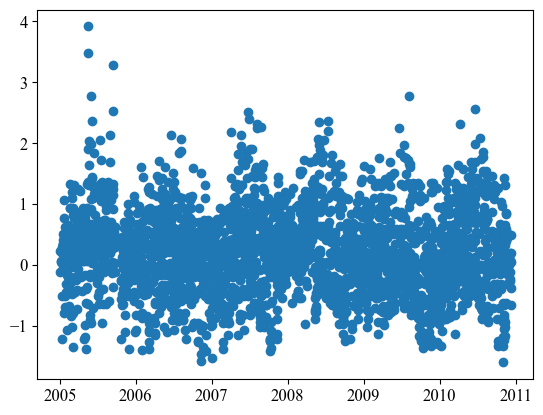

In [ ]:
plt.scatter(ts['datetime'],ts['Q3_fb_1'])

In [ ]:
import pandas as pd

all_data = []

for key, records in Grid_df.items():

    for record in records:

        fb = list(record.keys())[0]
        data = record[fb]

        all_data.append({
            'grid': key,
            'datetime': data['datetime'],
            'lat': data['lat'],
            'lon': data['lon'],
            'fb': fb,
            'Q3': data['Q3']
        })

temp_df = pd.DataFrame(all_data)

In [ ]:
temp_df

,grid,datetime,lat,lon,fb,Q3
0,G144,2005-01-01 00:05:36.579,67.5644,172.7907,fb_1,2.044331
1,G144,2005-01-01 00:05:36.579,67.5644,172.7907,fb_2,1.022945
2,G144,2005-01-01 00:05:36.579,67.5644,172.7907,fb_3,1.471744
3,G144,2005-01-01 00:05:36.579,67.5644,172.7907,fb_4,1.734324
4,G144,2005-01-01 00:05:36.579,67.5644,172.7907,fb_5,2.284716
...,...,...,...,...,...,...
5132815,G153,2010-10-07 11:16:43.967,71.4536,-0.1970,fb_7,0.737344
5132816,G153,2010-10-07 11:16:43.967,71.4536,-0.1970,fb_8,-0.371064
5132817,G153,2010-10-07 11:16:43.967,71.4536,-0.1970,fb_9,-1.147301
5132818,G153,2010-10-07 11:16:43.967,71.4536,-0.1970,fb_10,-2.372593


In [ ]:
import pandas as pd

all_data = []

for grid, records in Grid_df.items():

    for record in records:

        fb = list(record.keys())[0]
        data = record[fb]

        all_data.append({
            'datetime': data['datetime'],
            'grid': grid,
            'lat': data['lat'],
            'long': data['lon'],
            'fb': fb,
            'Q3': data['Q3']
        })

temp_df = pd.DataFrame(all_data)

# Convert fb_1, fb_2, ... into columns
df_full = temp_df.pivot(
    index=['datetime', 'grid', 'lat', 'long'],
    columns='fb',
    values='Q3'
).reset_index()

# Remove the columns index name
df_full.columns.name = None

# Rename fb_1 -> Q3_fb_1, etc.
df_full = df_full.rename(
    columns={f'fb_{i}': f'Q3_fb_{i}' for i in range(1, 12)}
)

# Ensure desired column order
df_full = df_full[
    ['datetime', 'grid', 'lat', 'long'] +
    [f'Q3_fb_{i}' for i in range(1, 12)]
]

In [ ]:
df_full

,datetime,grid,lat,long,Q3_fb_1,Q3_fb_2,Q3_fb_3,Q3_fb_4,Q3_fb_5,Q3_fb_6,Q3_fb_7,Q3_fb_8,Q3_fb_9,Q3_fb_10,Q3_fb_11
0,2005-01-01 00:05:36.579,G144,67.5644,172.7907,2.044331,1.022945,1.471744,1.734324,2.284716,1.861404,1.518998,1.232212,1.132497,0.986470,0.913925
1,2005-01-01 00:07:39.459,G144,60.5094,166.5650,0.936488,0.350716,0.797767,1.653489,2.114328,1.770686,1.396183,1.121392,1.039005,0.800572,0.314551
2,2005-01-01 00:09:42.540,G144,53.2904,162.4045,-0.004689,-0.201933,0.297729,2.006430,1.605140,0.917647,0.494877,0.228925,0.178038,-0.073968,-0.356579
3,2005-01-01 00:11:45.420,G125,46.0087,159.3144,-0.318414,-0.473562,0.964396,2.050502,0.831861,0.159565,-0.344529,-0.675444,-0.820042,-1.052359,-1.208733
4,2005-01-01 00:13:48.077,G125,38.7005,156.8341,-0.632140,-0.669641,1.552017,1.900750,0.315368,-0.467886,-0.961850,-1.267790,-1.548786,-1.819926,-2.001766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466615,2010-12-16 17:25:11.610,G39,-36.9934,-123.8308,-0.815815,-0.944151,1.397587,0.991679,-1.349196,-1.688806,-2.088845,-2.319499,-2.477325,-2.478077,-2.576271
466616,2010-12-16 17:27:14.490,G39,-44.3788,-126.1590,-0.737384,-1.221541,-0.677741,1.501482,-0.483902,-0.694723,-1.065925,-1.402416,-1.787136,-2.072353,-2.277357
466617,2010-12-16 17:29:17.370,G21,-51.7250,-129.0128,-1.011893,-0.907815,-0.952250,1.300547,0.268720,-0.117582,-0.203833,-0.236847,-0.335339,-0.562918,-1.260851
466618,2010-12-16 17:31:20.250,G21,-59.0049,-132.7760,-0.658952,-0.431350,-0.403231,1.224520,1.199824,0.988297,0.972638,0.988076,0.862013,0.788778,0.232447


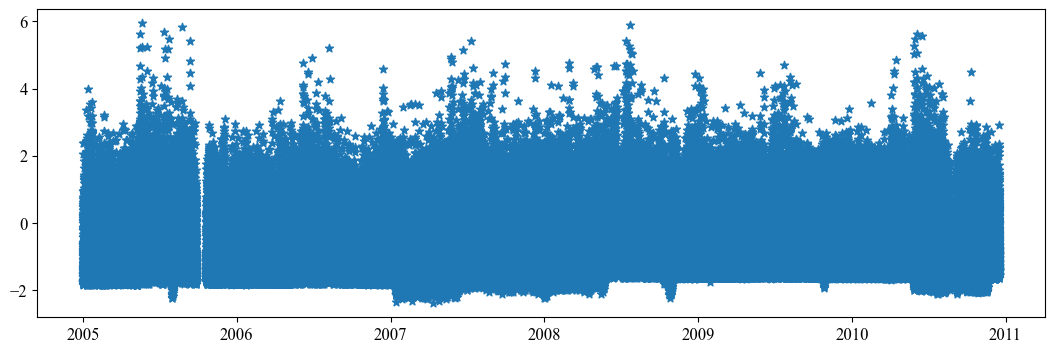

In [ ]:
fig = plt.subplots(figsize=(13,4))
plt.scatter(x=df_full['datetime'], y=df_full['Q3_fb_1'], marker="*")

Consolidate Timeseries

In [ ]:
gdf = pd.read_pickle("D:\GIT\Demeter-Anomaly-Detection-Framework\Data\Down_Orbits-Q3-loc-Train-limitedgrids_RES.pkl")

In [ ]:
gdf_new = gdf.drop(columns=gdf.filter(regex=r'^Res_Q3_fb_').columns)

In [ ]:
gdf_new.to_pickle("D:\GIT\Demeter-Anomaly-Detection-Framework\Data\ICE-Down_Orbits-Q3-limitedgrids.pkl")

In [ ]:
gdf

,Q3_fb_1,lat,lon,Res_Q3_fb_1,Q3_fb_2,Res_Q3_fb_2,Q3_fb_3,Res_Q3_fb_3,Q3_fb_4,Res_Q3_fb_4,...,Q3_fb_7,Res_Q3_fb_7,Q3_fb_8,Res_Q3_fb_8,Q3_fb_9,Res_Q3_fb_9,Q3_fb_10,Res_Q3_fb_10,Q3_fb_11,Res_Q3_fb_11
datetime,,,,,,,,,,,,,,,,,,,,,
2005-01-01 00:05:36.579,2.044331,67.5644,172.7907,1.828858,1.022945,1.422316,1.471744,1.485098,1.734324,0.365655,...,1.518998,0.180102,1.232212,0.128261,1.132497,0.240991,0.986470,0.618205,0.913925,1.046810
2005-01-01 00:07:39.459,0.936488,60.5094,166.5650,0.721016,0.350716,0.750089,0.797767,0.811125,1.653489,0.284825,...,1.396183,0.057292,1.121392,0.017445,1.039005,0.147505,0.800572,0.432312,0.314551,0.447442
2005-01-01 00:09:42.540,-0.004689,53.2904,162.4045,-0.220159,-0.201933,0.197442,0.297729,0.311090,2.006430,0.637771,...,0.494877,-0.844008,0.228925,-0.875017,0.178038,-0.713458,-0.073968,-0.442223,-0.356579,-0.223682
2005-01-01 00:11:45.420,-0.318414,46.0087,159.3144,0.630721,-0.473562,0.640605,0.964396,0.596627,2.050502,0.927470,...,-0.344529,0.329737,-0.675444,0.378596,-0.820042,0.638381,-1.052359,0.692393,-1.208733,0.798213
2005-01-01 00:13:48.077,-0.632140,38.7005,156.8341,0.316999,-0.669641,0.444535,1.552017,1.184258,1.900750,0.777726,...,-0.961850,-0.287579,-1.267790,-0.213745,-1.548786,-0.090359,-1.819926,-0.075169,-2.001766,0.005183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010-12-16 17:25:11.610,-0.815815,-36.9934,-123.8308,-0.009683,-0.944151,0.470400,1.397587,1.116015,0.991679,0.561714,...,-2.088845,-0.036247,-2.319499,-0.003479,-2.477325,0.101927,-2.478077,0.291335,-2.576271,0.265015
2010-12-16 17:27:14.490,-0.737384,-44.3788,-126.1590,0.068747,-1.221541,0.193008,-0.677741,-0.959314,1.501482,1.071517,...,-1.065925,0.986678,-1.402416,0.913608,-1.787136,0.792120,-2.072353,0.697062,-2.277357,0.563932
2010-12-16 17:29:17.370,-1.011893,-51.7250,-129.0128,-0.176642,-0.907815,0.791706,-0.952250,0.343836,1.300547,1.000967,...,-0.203833,0.399193,-0.236847,0.679890,-0.335339,1.168828,-0.562918,1.424849,-1.260851,1.240434
